Task 3 - Transfer Learning with ResNet50

This notebook implements transfer learning for binary classification of knee X-ray images into healthy (0) and osteoarthritis (1) using a pretrained ResNet50 model.

In [2]:
pip install torch torchvision


Note: you may need to restart the kernel to use updated packages.


In [3]:
import os
import time
import copy
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader, ConcatDataset

from torchvision.models import resnet50, ResNet50_Weights

from sklearn.metrics import (
    accuracy_score,
    recall_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix
)

print("PyTorch version:", torch.__version__)

PyTorch version: 2.11.0+cpu


In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [5]:
X_train = np.load("X_train.npy")
y_train = np.load("y_train.npy")

X_val = np.load("X_val.npy")
y_val = np.load("y_val.npy")

X_test = np.load("X_test.npy")
y_test = np.load("y_test.npy")

X_test_no_normalized = np.load("X_test_no_norm.npy")

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_val shape:", X_val.shape)
print("y_val shape:", y_val.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (1500, 128, 128, 1)
y_train shape: (1500,)
X_val shape: (159, 128, 128, 1)
y_val shape: (159,)
X_test shape: (146, 128, 128, 1)
y_test shape: (146,)


In [6]:
def to_3_channels(x):
    """
    Converts grayscale images to 3 channels by repeating the channel dimension.
    Expected input shape: (N, H, W, 1) or (N, 1, H, W) or (N, H, W)
    Output shape: (N, 3, H, W)
    """
    if x.ndim == 3:  # (N, H, W)
        x = np.expand_dims(x, axis=-1)

    if x.shape[-1] == 1:  # (N, H, W, 1)
        x = np.transpose(x, (0, 3, 1, 2))  # -> (N, 1, H, W)

    if x.shape[1] == 1:  # (N, 1, H, W)
        x = np.repeat(x, 3, axis=1)  # -> (N, 3, H, W)

    return x.astype(np.float32)

X_train_3 = to_3_channels(X_train)
X_val_3 = to_3_channels(X_val)
X_test_3 = to_3_channels(X_test)

print("X_train_3 shape:", X_train_3.shape)
print("X_val_3 shape:", X_val_3.shape)
print("X_test_3 shape:", X_test_3.shape)

X_train_3 shape: (1500, 3, 128, 128)
X_val_3 shape: (159, 3, 128, 128)
X_test_3 shape: (146, 3, 128, 128)


In [7]:
X_train_tensor = torch.tensor(X_train_3, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)

X_val_tensor = torch.tensor(X_val_3, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.float32)

X_test_tensor = torch.tensor(X_test_3, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)

In [8]:
batch_size = 16  # same spirit as baseline

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 94
Val batches: 10
Test batches: 10


In [9]:
def compute_specificity(y_true, y_pred_binary):
    cm = confusion_matrix(y_true, y_pred_binary)
    tn, fp, fn, tp = cm.ravel()
    return tn / (tn + fp) if (tn + fp) > 0 else 0.0

def evaluate_metrics(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)

    acc = accuracy_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)  # sensitivity
    spec = compute_specificity(y_true, y_pred)
    auc = roc_auc_score(y_true, y_prob)

    return {
        "accuracy": acc,
        "recall": rec,
        "specificity": spec,
        "roc_auc": auc
    }

A pretrained ResNet50 model is used as the base architecture. 
The model is initialized with ImageNet weights, the final fully connected layer is removed, and all base layers are frozen.
New fully connected layers are added on top of the base model to adapt it to the binary classification task, including a dropout layer to reduce overfitting.

In [10]:
class TransferResNet50(nn.Module):
    def __init__(self, dropout_rate=0.5):
        super().__init__()

        # Load pretrained ResNet50
        self.base_model = resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)

        # Remove the final fully connected layer
        num_features = self.base_model.fc.in_features
        self.base_model.fc = nn.Identity()

        # Freeze all layers in the base model
        for param in self.base_model.parameters():
            param.requires_grad = False

        # New classification head
        self.classifier = nn.Sequential(
            nn.Linear(num_features, 256),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(256, 1)
        )

    def forward(self, x):
        features = self.base_model(x)
        output = self.classifier(features)
        return output

In [11]:
model = TransferResNet50(dropout_rate=0.5).to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.classifier.parameters(), lr=1e-4)

print(model)

TransferResNet50(
  (base_model): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequential

The model is trained using the best hyperparameters from the baseline (when applicable), with the same loss function and evaluation metrics as in Task 2. Training and validation losses are monitored to ensure correct execution and smooth convergence. Training curves are plotted, and a limited, systematic hyperparameter tuning is performed.

In [12]:
def count_trainable_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print("Trainable parameters:", count_trainable_parameters(model))

Trainable parameters: 524801


In [13]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0

    for inputs, labels in loader:
        inputs = inputs.to(device)
        labels = labels.to(device).unsqueeze(1)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)

    epoch_loss = running_loss / len(loader.dataset)
    return epoch_loss


def evaluate_loss_and_probs(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0

    all_labels = []
    all_probs = []

    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device)
            labels = labels.to(device).unsqueeze(1)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            probs = torch.sigmoid(outputs)

            running_loss += loss.item() * inputs.size(0)
            all_labels.extend(labels.cpu().numpy().ravel())
            all_probs.extend(probs.cpu().numpy().ravel())

    epoch_loss = running_loss / len(loader.dataset)
    return epoch_loss, np.array(all_labels), np.array(all_probs)

In [14]:
def train_model(model, train_loader, val_loader, criterion, optimizer, device, epochs=10):
    history = {
        "train_loss": [],
        "val_loss": [],
        "val_accuracy": [],
        "val_recall": [],
        "val_specificity": [],
        "val_roc_auc": []
    }

    best_model_wts = copy.deepcopy(model.state_dict())
    best_val_auc = 0.0

    start_time = time.time()

    for epoch in range(epochs):
        train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, y_val_true, y_val_prob = evaluate_loss_and_probs(model, val_loader, criterion, device)

        metrics_dict = evaluate_metrics(y_val_true, y_val_prob, threshold=0.5)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_accuracy"].append(metrics_dict["accuracy"])
        history["val_recall"].append(metrics_dict["recall"])
        history["val_specificity"].append(metrics_dict["specificity"])
        history["val_roc_auc"].append(metrics_dict["roc_auc"])

        if metrics_dict["roc_auc"] > best_val_auc:
            best_val_auc = metrics_dict["roc_auc"]
            best_model_wts = copy.deepcopy(model.state_dict())

        print(
            f"Epoch {epoch+1}/{epochs} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {metrics_dict['accuracy']:.4f} | "
            f"Val Recall: {metrics_dict['recall']:.4f} | "
            f"Val Spec: {metrics_dict['specificity']:.4f} | "
            f"Val AUC: {metrics_dict['roc_auc']:.4f}"
        )

    total_time = time.time() - start_time
    print(f"\nTraining completed in {total_time:.2f} seconds")

    model.load_state_dict(best_model_wts)
    return model, history

In [15]:
initial_epochs = 10

model, history = train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    device,
    epochs=initial_epochs
)

Epoch 1/10 | Train Loss: 0.6313 | Val Loss: 0.6311 | Val Acc: 0.6038 | Val Recall: 0.0000 | Val Spec: 1.0000 | Val AUC: 0.7323
Epoch 2/10 | Train Loss: 0.5796 | Val Loss: 0.5958 | Val Acc: 0.6478 | Val Recall: 0.1111 | Val Spec: 1.0000 | Val AUC: 0.7872
Epoch 3/10 | Train Loss: 0.5289 | Val Loss: 0.5580 | Val Acc: 0.6981 | Val Recall: 0.2381 | Val Spec: 1.0000 | Val AUC: 0.8290
Epoch 4/10 | Train Loss: 0.4932 | Val Loss: 0.5174 | Val Acc: 0.7547 | Val Recall: 0.4286 | Val Spec: 0.9688 | Val AUC: 0.8452
Epoch 5/10 | Train Loss: 0.4655 | Val Loss: 0.5201 | Val Acc: 0.7484 | Val Recall: 0.3810 | Val Spec: 0.9896 | Val AUC: 0.8441
Epoch 6/10 | Train Loss: 0.4413 | Val Loss: 0.4695 | Val Acc: 0.7673 | Val Recall: 0.4762 | Val Spec: 0.9583 | Val AUC: 0.8700
Epoch 7/10 | Train Loss: 0.4284 | Val Loss: 0.4489 | Val Acc: 0.7862 | Val Recall: 0.6190 | Val Spec: 0.8958 | Val AUC: 0.8707
Epoch 8/10 | Train Loss: 0.3868 | Val Loss: 0.5073 | Val Acc: 0.7484 | Val Recall: 0.3651 | Val Spec: 1.0000 | 

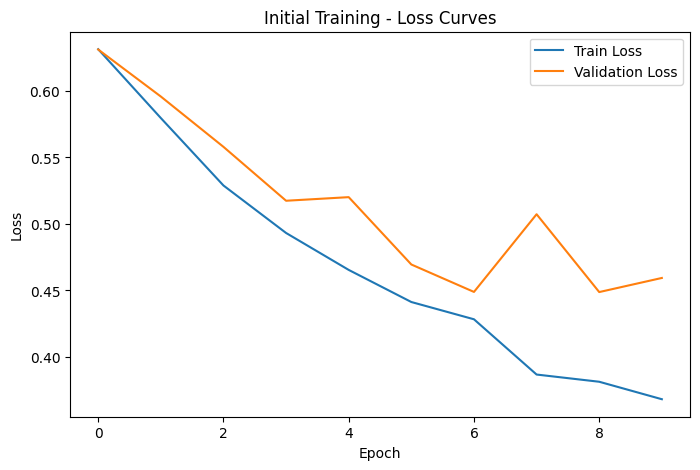

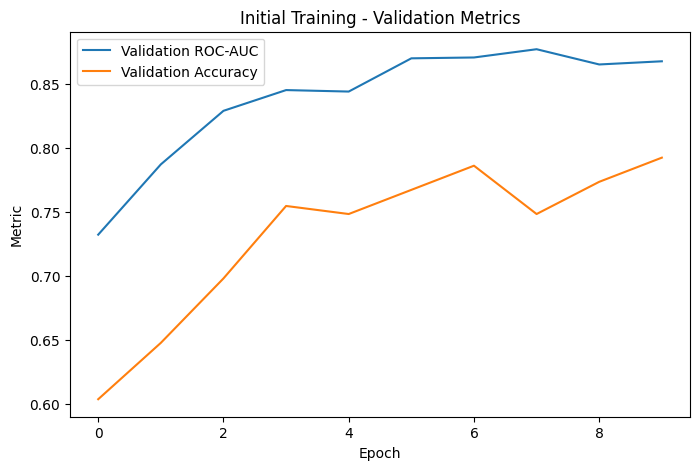

In [16]:
plt.figure(figsize=(8, 5))
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Initial Training - Loss Curves")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history["val_roc_auc"], label="Validation ROC-AUC")
plt.plot(history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Metric")
plt.title("Initial Training - Validation Metrics")
plt.legend()
plt.show()

The model is retrained using the complete training dataset (including the validation set) with the previously selected optimal hyperparameters. The training curve is plotted to monitor the learning process, and the final model is saved and reloaded.

In [17]:
full_train_dataset = ConcatDataset([train_dataset, val_dataset])
full_train_loader = DataLoader(full_train_dataset, batch_size=batch_size, shuffle=True)

print("Full training set size:", len(full_train_dataset))

Full training set size: 1659


In [18]:
final_model = TransferResNet50(dropout_rate=0.5).to(device)

final_criterion = nn.BCEWithLogitsLoss()
final_optimizer = optim.Adam(final_model.classifier.parameters(), lr=1e-4)

print(final_model)

TransferResNet50(
  (base_model): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequential

In [19]:
def train_full_model(model, loader, criterion, optimizer, device, epochs=10):
    history = {"train_loss": []}

    for epoch in range(epochs):
        train_loss = train_one_epoch(model, loader, criterion, optimizer, device)
        history["train_loss"].append(train_loss)

        print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_loss:.4f}")

    return model, history

final_model, full_history = train_full_model(
    final_model,
    full_train_loader,
    final_criterion,
    final_optimizer,
    device,
    epochs=initial_epochs
)

Epoch 1/10 | Train Loss: 0.6293
Epoch 2/10 | Train Loss: 0.5682
Epoch 3/10 | Train Loss: 0.5089
Epoch 4/10 | Train Loss: 0.4721
Epoch 5/10 | Train Loss: 0.4505
Epoch 6/10 | Train Loss: 0.4237
Epoch 7/10 | Train Loss: 0.4165
Epoch 8/10 | Train Loss: 0.4068
Epoch 9/10 | Train Loss: 0.3878
Epoch 10/10 | Train Loss: 0.3851


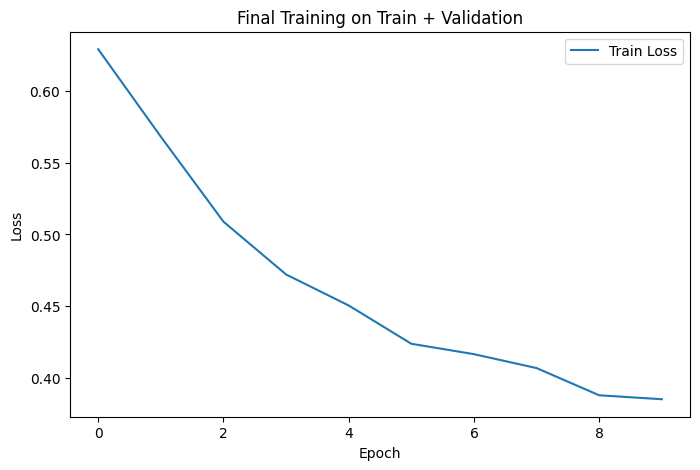

In [20]:
plt.figure(figsize=(8, 5))
plt.plot(full_history["train_loss"], label="Train Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Final Training on Train + Validation")
plt.legend()
plt.show()

In [21]:
torch.save(final_model.state_dict(), "resnet50_transfer_initial.pth")
print("Model saved.")

reloaded_model = TransferResNet50(dropout_rate=0.5).to(device)
reloaded_model.load_state_dict(torch.load("resnet50_transfer_initial.pth", map_location=device))
reloaded_model.eval()

print("Model reloaded successfully.")

Model saved.
Model reloaded successfully.


The pretrained model is unfrozen and trained end-to-end using the same number of epochs with a smaller learning rate. If a performance drop is observed, the model is reloaded and retrained with adjusted parameters; otherwise, the previous model is retained.

The final model is evaluated on the test set using the selected metrics. A confusion matrix is displayed, and a subset of test images (without preprocessing) is visualized along with their predicted labels.

In [22]:
for param in reloaded_model.base_model.parameters():
    param.requires_grad = True

fine_tune_optimizer = optim.Adam(reloaded_model.parameters(), lr=1e-5)
fine_tune_criterion = nn.BCEWithLogitsLoss()

print("All base model layers have been unfrozen for fine-tuning.")
print("Trainable parameters after unfreezing:", count_trainable_parameters(reloaded_model))

All base model layers have been unfrozen for fine-tuning.
Trainable parameters after unfreezing: 24032833


In [23]:
fine_tuned_model, fine_tune_history = train_full_model(
    reloaded_model,
    full_train_loader,
    fine_tune_criterion,
    fine_tune_optimizer,
    device,
    epochs=initial_epochs
)

Epoch 1/10 | Train Loss: 0.3406
Epoch 2/10 | Train Loss: 0.2446
Epoch 3/10 | Train Loss: 0.1986
Epoch 4/10 | Train Loss: 0.1424
Epoch 5/10 | Train Loss: 0.1103
Epoch 6/10 | Train Loss: 0.0872
Epoch 7/10 | Train Loss: 0.0489
Epoch 8/10 | Train Loss: 0.0516
Epoch 9/10 | Train Loss: 0.0467
Epoch 10/10 | Train Loss: 0.0298


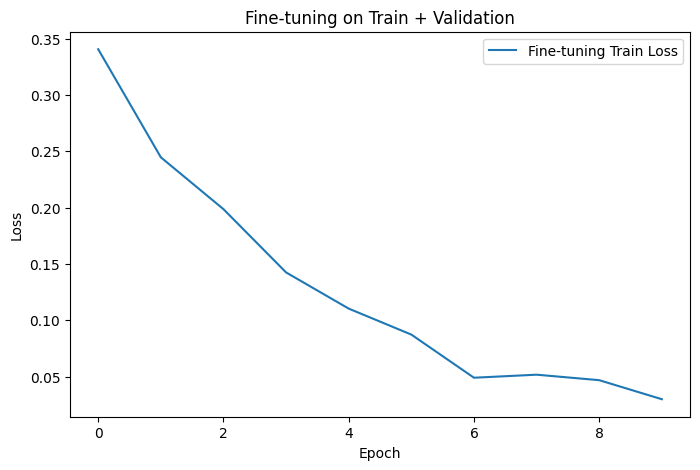

In [24]:
plt.figure(figsize=(8, 5))
plt.plot(fine_tune_history["train_loss"], label="Fine-tuning Train Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Fine-tuning on Train + Validation")
plt.legend()
plt.show()

In [25]:
torch.save(fine_tuned_model.state_dict(), "resnet50_transfer_finetuned.pth")
print("Fine-tuned model saved.")

Fine-tuned model saved.


In [26]:
test_loss, y_test_true, y_test_prob = evaluate_loss_and_probs(
    fine_tuned_model,
    test_loader,
    fine_tune_criterion,
    device
)

test_metrics = evaluate_metrics(y_test_true, y_test_prob, threshold=0.5)

print("Test Loss:", round(test_loss, 4))
print("Test Accuracy:", round(test_metrics["accuracy"], 4))
print("Test Recall (Sensitivity):", round(test_metrics["recall"], 4))
print("Test Specificity:", round(test_metrics["specificity"], 4))
print("Test ROC-AUC:", round(test_metrics["roc_auc"], 4))

Test Loss: 0.25
Test Accuracy: 0.9384
Test Recall (Sensitivity): 0.92
Test Specificity: 0.9479
Test ROC-AUC: 0.9527


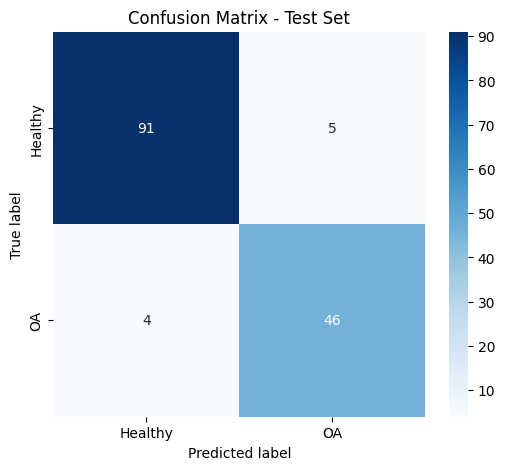

In [27]:
y_test_pred = (y_test_prob >= 0.5).astype(int)
cm = confusion_matrix(y_test_true, y_test_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Healthy", "OA"],
            yticklabels=["Healthy", "OA"])
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix - Test Set")
plt.show()


A subset of test images (without preprocessing) is displayed along with their predicted labels. This step allows to visualize model predictions on raw input data.

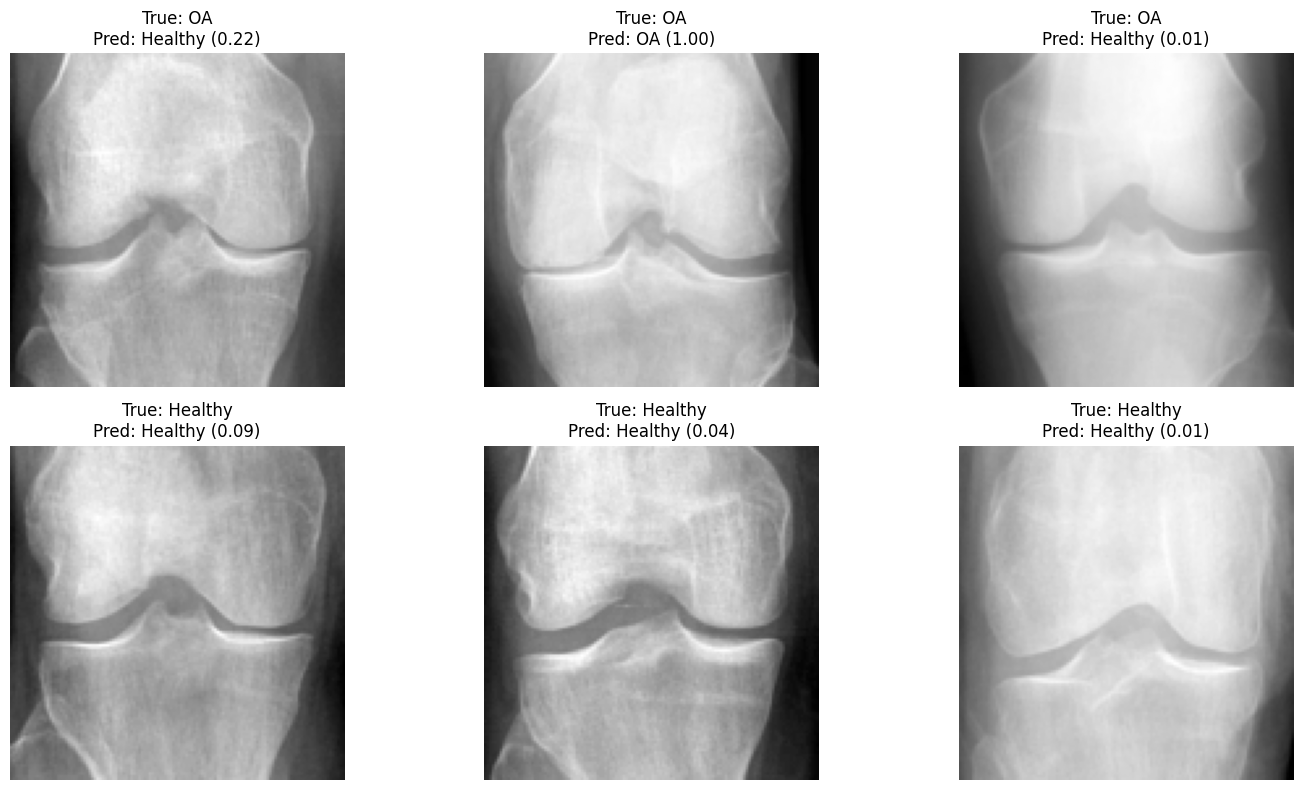

In [28]:
class_names = {0: "Healthy", 1: "OA"}

num_samples = 6
indices = np.random.choice(len(X_test), num_samples, replace=False)

plt.figure(figsize=(15, 8))

for i, idx in enumerate(indices):
    img_input = torch.tensor(X_test_3[idx:idx+1], dtype=torch.float32).to(device)

    fine_tuned_model.eval()
    with torch.no_grad():
        logit = fine_tuned_model(img_input)
        prob = torch.sigmoid(logit).item()
        pred = int(prob >= 0.5)

    img_vis = X_test_no_normalized[idx]

    if img_vis.ndim == 3 and img_vis.shape[-1] == 1:
        img_vis = img_vis.squeeze(-1)
    elif img_vis.ndim == 3 and img_vis.shape[0] == 1:
        img_vis = img_vis.squeeze(0)

    true_label = int(y_test[idx])

    plt.subplot(2, 3, i + 1)
    plt.imshow(img_vis, cmap="gray")
    plt.title(
        f"True: {class_names[true_label]}\n"
        f"Pred: {class_names[pred]} ({prob:.2f})"
    )
    plt.axis("off")

plt.tight_layout()
plt.show()